# App-23 — Cryptanalyse différentielle de PRESENT par SAT

> **Navigation** : [Applications Search](../README.md) · [IA symbolique](../../../SymbolicAI/README.md) · [SMT / Z3](../../../SymbolicAI/SMT/README.md)

## Objectifs d'apprentissage

À la fin de ce notebook, vous saurez :

1. construire et lire la table de distribution différentielle (DDT) d'une S-box ;
2. traduire une relation finie en CNF compacte par implicants ;
3. transformer une optimisation en une suite de décisions SAT bornées ;
4. distinguer une **preuve de satisfiabilité**, une **certification UNSAT bornée** et une preuve formelle ;
5. expliquer pourquoi le meilleur *trail* n'est pas un *cluster* différentiel.

**Prérequis** : logique propositionnelle, CNF, bases de cryptographie symétrique. **Durée estimée** : 55 min.

## Hommage à un travail étudiant

Ce notebook distille le projet F2 de **Théodore Deguest**, réalisé en solo pour le cours EPITA SCIA *Programmation par Contraintes* 2026 :

- [répertoire source — `F2-Cryptanalyse-differentielle-par-SAT`](https://github.com/jsboigeEpita/2026-Epita-Programmation-par-Contraintes/tree/main/F2-Cryptanalyse-differentielle-par-SAT) ;
- [PR source #49](https://github.com/jsboigeEpita/2026-Epita-Programmation-par-Contraintes/pull/49).

L'appareil étudiant apporte le geste central — `DDT → implicants → CNF/PB → décisions SAT bornées` — ainsi que les comparaisons CaDiCaL/Kissat. CoursIA réécrit l'expérience en petit, la reproduit fraîchement et la relie aux contenus SAT, MaxSAT, SMT et bit-vectors déjà présents. Les corrections et limites restent visibles : poids ≠ nombre de S-box actives ; meilleur trail ≠ cluster ; certification bornée ≠ preuve formelle.

## 1. Environnement et contrat reproductible

Le notebook utilise **PySAT** avec CaDiCaL. Aucun binaire externe Kissat ni `pypblib` compilé séparément n'est requis : l'encodage de cardinalité séquentiel fourni par PySAT suffit ici.

In [1]:
from collections import Counter
from math import log2

import numpy as np
import matplotlib.pyplot as plt
from pysat.card import CardEnc, EncType
from pysat.formula import CNF
from pysat.solvers import Cadical195

print("Environnement prêt : NumPy, Matplotlib et PySAT/CaDiCaL chargés")

Environnement prêt : NumPy, Matplotlib et PySAT/CaDiCaL chargés


**Interprétation.** Les questions SAT/UNSAT sont reproductibles : aucune donnée distante ni graine aléatoire n'intervient, et le modèle cryptographique ainsi que l'ordre des bornes restent fixes. La compression gloutonne de la relation est correcte sur tout le domaine fini vérifié, mais le nombre de clauses peut varier avec l'ordre de départage des implicants ex æquo ; cette limite est explicitée en section 4. CaDiCaL répond aux décisions, tandis que la boucle Python porte l'optimisation par bornes successives.

## 2. PRESENT : vérifier le chiffrement avant d'attaquer son modèle différentiel

PRESENT est un réseau substitution-permutation (SPN) sur blocs de 64 bits. Une couche applique 16 fois la même S-box 4 bits, puis permute les 64 bits. Avant toute cryptanalyse, quatre vecteurs officiels protègent contre une erreur d'implémentation silencieuse.

In [2]:
SBOX = [0xC, 0x5, 0x6, 0xB, 0x9, 0x0, 0xA, 0xD,
        0x3, 0xE, 0xF, 0x8, 0x4, 0x7, 0x1, 0x2]
P = [16 * i if i < 4 else (i // 4) + 16 * (i % 4) for i in range(63)] + [63]


def round_keys(key):
    keys = [key]
    for round_index in range(1, 32):
        key = (key >> 19) | ((key << 61) & ((1 << 80) - 1))
        key = (key & ((1 << 76) - 1)) | (SBOX[key >> 76] << 76)
        key ^= round_index << 15
        keys.append(key)
    return keys


def encrypt(plaintext, key):
    state = plaintext
    keys = round_keys(key)
    for round_index in range(31):
        state ^= keys[round_index] >> 16
        state = sum(SBOX[(state >> (4 * i)) & 0xF] << (4 * i) for i in range(16))
        state = sum(((state >> i) & 1) << P[i] for i in range(64))
    return state ^ (keys[31] >> 16)


vectors = [
    (0x0000000000000000, 0x00000000000000000000, 0x5579C1387B228445),
    (0x0000000000000000, 0xFFFFFFFFFFFFFFFFFFFF, 0xE72C46C0F5945049),
    (0xFFFFFFFFFFFFFFFF, 0x00000000000000000000, 0xA112FFC72F68417B),
    (0xFFFFFFFFFFFFFFFF, 0xFFFFFFFFFFFFFFFFFFFF, 0x3333DCD3213210D2),
]
checks = [encrypt(plaintext, key) == expected for plaintext, key, expected in vectors]
print(f"Vecteurs PRESENT validés : {sum(checks)}/{len(checks)}")
assert all(checks)

Vecteurs PRESENT validés : 4/4


**Interprétation.** Les quatre vecteurs passent. Cette vérification porte sur le chiffrement, pas encore sur l'encodage différentiel : deux couches de confiance séparées valent mieux qu'un unique résultat final.

## 3. La DDT : passer des différences aux probabilités

Pour une différence d'entrée `a` et une différence de sortie `b`, la DDT compte les valeurs `x` telles que `S(x) XOR S(x XOR a) = b`.

Une entrée nulle interdit la transition ; une entrée 4 donne une probabilité 4/16 et un poids `-log2(4/16)=2` ; une entrée 2 donne un poids 3.

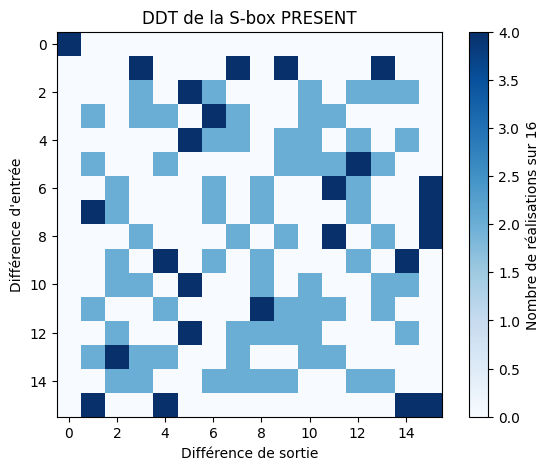

Valeurs DDT : {np.int64(0): 159, np.int64(2): 72, np.int64(4): 24, np.int64(16): 1}
Transitions non nulles par poids : {2: 24, 3: 72}


In [3]:
def build_ddt(sbox):
    ddt = np.zeros((len(sbox), len(sbox)), dtype=int)
    for delta_in in range(len(sbox)):
        for x in range(len(sbox)):
            delta_out = sbox[x] ^ sbox[x ^ delta_in]
            ddt[delta_in, delta_out] += 1
    return ddt


DDT = build_ddt(SBOX)
counts = Counter(DDT.ravel())
transition_weights = Counter(
    int(-log2(value / 16))
    for delta_in in range(1, 16)
    for value in DDT[delta_in]
    if value
)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(DDT, cmap="Blues", vmin=0, vmax=4)
ax.set(title="DDT de la S-box PRESENT", xlabel="Différence de sortie", ylabel="Différence d'entrée")
fig.colorbar(im, ax=ax, label="Nombre de réalisations sur 16")
plt.show()
print(f"Valeurs DDT : {dict(sorted(counts.items()))}")
print(f"Transitions non nulles par poids : {dict(sorted(transition_weights.items()))}")
assert counts == Counter({0: 159, 2: 72, 4: 24, 16: 1})

**Interprétation.** Hors transition triviale `0→0`, la S-box possède **24 transitions légères de poids 2** (DDT=4) et **72 transitions lourdes de poids 3** (DDT=2). L'oral et une première review avaient inversé ces adjectifs ; le calcul exécutable tranche l'ambiguïté.

### Exercice 1 — Auditer une S-box modifiée

Modifiez une valeur de `SBOX`, reconstruisez sa DDT puis vérifiez : somme de chaque ligne, nombre de transitions possibles et poids maximal observé.

In [4]:
# TODO étudiant : construire modified_ddt et vérifier ses invariants.
modified_ddt = None
print("Exercice a completer")

Exercice a completer


**Point de contrôle.** Une DDT valide a toujours des lignes de somme 16. Cette propriété est nécessaire, mais ne suffit pas à garantir qu'une S-box est cryptographiquement robuste.

## 4. De 159 interdictions à une CNF compacte

L'encodage naïf ajoute une clause pour chaque transition impossible. Théodore Deguest applique une minimisation de type Quine–McCluskey sur les minterms interdits : chaque implicant sélectionné interdit tout un sous-cube sans jamais couvrir une transition valide.

In [5]:
def compact_forbidden_clauses(valid, width):
    universe = set(range(1 << width))
    invalid = universe - set(valid)
    current = {(value, 0) for value in invalid}
    primes = set()
    mask_all = (1 << width) - 1

    while current:
        merged, used = set(), set()
        terms = list(current)
        for i, (value_a, mask_a) in enumerate(terms):
            for value_b, mask_b in terms[i + 1:]:
                if mask_a != mask_b:
                    continue
                diff = (value_a ^ value_b) & ~mask_a & mask_all
                if diff == 0 or diff & (diff - 1):
                    continue
                new_mask = mask_a | diff
                new_value = value_a & ~diff & mask_all
                if not any((item & ~new_mask) == new_value for item in valid):
                    merged.add((new_value, new_mask))
                    used.update({(value_a, mask_a), (value_b, mask_b)})
        primes.update(current - used)
        current = merged

    coverage = {
        prime: {item for item in invalid if (item & ~prime[1]) == prime[0]}
        for prime in primes
    }
    selected, uncovered = [], set(invalid)
    while uncovered:
        best = max(coverage, key=lambda prime: len(coverage[prime] & uncovered))
        selected.append(best)
        uncovered -= coverage[best]
        coverage = {prime: covered for prime, covered in coverage.items() if covered & uncovered}
    return selected


def is_forbidden(code, implicant):
    value, mask = implicant
    return (code & ~mask) == value


valid_8 = {delta_in | (delta_out << 4)
           for delta_in in range(16) for delta_out in range(16)
           if DDT[delta_in, delta_out] > 0}
valid_10 = {0}
for delta_in in range(1, 16):
    for delta_out in range(16):
        if DDT[delta_in, delta_out] == 4:
            valid_10.add(delta_in | (delta_out << 4) | (1 << 8))
        elif DDT[delta_in, delta_out] == 2:
            valid_10.add(delta_in | (delta_out << 4) | (1 << 8) | (1 << 9))

compact_8 = compact_forbidden_clauses(valid_8, 8)
compact_10 = compact_forbidden_clauses(valid_10, 10)
for width, valid, compact in [(8, valid_8, compact_8), (10, valid_10, compact_10)]:
    accepted = {code for code in range(1 << width)
                if not any(is_forbidden(code, implicant) for implicant in compact)}
    assert accepted == valid

print(f"Relation DDT 8 bits : {256 - len(valid_8)} interdictions naïves → {len(compact_8)} clauses")
print(f"Relation DDT+poids 10 bits : {1024 - len(valid_10)} interdictions naïves → {len(compact_10)} clauses")

Relation DDT 8 bits : 159 interdictions naïves → 41 clauses
Relation DDT+poids 10 bits : 927 interdictions naïves → 59 clauses


**Interprétation.** La reproduction retrouve **159→41 clauses** pour la relation 8 bits. Pour la relation pondérée 10 bits, la couverture gloutonne fraîche obtient **927→59 clauses**, contre 64 dans l'exécution étudiante archivée : les deux couvertures sont exhaustivement équivalentes à la même relation, mais le choix parmi des implicants ex æquo dépend de l'ordre d'itération des ensembles Python. L'égalité exhaustive des ensembles acceptés vérifie ici la correction sur tout le domaine fini ; elle ne constitue pas une preuve générale de l'algorithme de minimisation.

### Exercice 2 — Mesurer la qualité d'un encodage

Comparez l'encodage compact à un encodage naïf sur une S-box jouet : nombre de clauses, longueur moyenne, puis temps SAT sur une petite conjonction de S-box.

In [6]:
# TODO étudiant : produire naive_stats et compact_stats.
naive_stats = compact_stats = None
print("Exercice a completer")

Exercice a completer


**Point de contrôle.** Moins de clauses n'implique pas automatiquement une meilleure propagation. Une comparaison honnête mesure aussi la taille des clauses et l'effort du solveur.

## 5. Encoder les trails de PRESENT

Chaque frontière de tour reçoit 64 variables de différence. Pour chaque S-box, les quatre bits d'entrée et les quatre bits de sortie permutés doivent former une transition admise par la DDT. Deux bits auxiliaires portent le coût : `active` vaut 1 si l'entrée est non nulle ; `heavy` vaut 1 pour une transition DDT=2. Le poids du trail vaut `W = 2 * sum(active) + sum(heavy)`.

In [7]:
def clause_templates(implicants, width):
    templates = []
    for value, mask in implicants:
        templates.append([(bit, not bool((value >> bit) & 1))
                          for bit in range(width) if not ((mask >> bit) & 1)])
    return templates


TEMPLATES_10 = clause_templates(compact_10, 10)


def diff_var(round_index, bit):
    return 1 + 64 * round_index + bit


def active_var(rounds, round_index, sbox_index):
    return 1 + 64 * (rounds + 1) + 16 * round_index + sbox_index


def heavy_var(rounds, round_index, sbox_index):
    return 1 + 64 * (rounds + 1) + 16 * rounds + 16 * round_index + sbox_index


def weighted_model(rounds, bound=None):
    cnf = CNF()
    for round_index in range(rounds):
        for sbox_index in range(16):
            variables = (
                [diff_var(round_index, 4 * sbox_index + bit) for bit in range(4)]
                + [diff_var(round_index + 1, P[4 * sbox_index + bit]) for bit in range(4)]
                + [active_var(rounds, round_index, sbox_index),
                   heavy_var(rounds, round_index, sbox_index)]
            )
            for template in TEMPLATES_10:
                cnf.append([variables[bit] if positive else -variables[bit]
                            for bit, positive in template])
    cnf.append([diff_var(0, bit) for bit in range(64)])
    cnf.append([diff_var(rounds, bit) for bit in range(64)])
    if bound is not None:
        # Une copie équivalente de chaque variable active transforme le poids 2
        # en deux littéraux distincts, sans dépendre de pypblib.
        weighted_literals = []
        next_variable = cnf.nv + 1
        for round_index in range(rounds):
            for sbox_index in range(16):
                active = active_var(rounds, round_index, sbox_index)
                active_copy = next_variable
                next_variable += 1
                cnf.append([-active_copy, active])
                cnf.append([-active, active_copy])
                weighted_literals += [active, active_copy,
                                      heavy_var(rounds, round_index, sbox_index)]
        cnf.extend(CardEnc.atmost(lits=weighted_literals, bound=bound,
                                  top_id=cnf.nv,
                                  encoding=EncType.seqcounter).clauses)
    return cnf


def sat_at_most(rounds, bound):
    cnf = weighted_model(rounds, bound)
    with Cadical195(bootstrap_with=cnf.clauses) as solver:
        sat = solver.solve()
        model = solver.get_model() if sat else None
    return sat, model, cnf


sample = weighted_model(3, bound=8)
print(f"Modèle 3 tours / W≤8 : {sample.nv} variables, {len(sample.clauses)} clauses")

Modèle 3 tours / W≤8 : 1488 variables, 5234 clauses


**Interprétation.** Le modèle relie structure cryptographique et optimisation pseudo-booléenne. Une borne sur `active` seule répondrait à une autre question : elle ignorerait la différence entre transitions de poids 2 et 3.

## 6. Optimiser par décisions : la frontière SAT / UNSAT

Un solveur SAT ne « minimise » pas directement. On pose une suite de questions : existe-t-il un trail de poids au plus `W` ? Le premier `SAT(W)` précédé de `UNSAT(W-1)` certifie le minimum **pour ce modèle, ces tours et cet encodage**.

In [8]:
reference_weights = {1: 2, 2: 4, 3: 8, 4: 12, 5: 20, 6: 24}
results = []
for rounds, expected in reference_weights.items():
    sat_below, _, _ = sat_at_most(rounds, expected - 1)
    sat_at, _, formula = sat_at_most(rounds, expected)
    results.append((rounds, expected, sat_below, sat_at, formula.nv, len(formula.clauses)))
    assert not sat_below and sat_at

print("R | minimum | SAT(W-1) | SAT(W) | variables | clauses")
for row in results:
    print(f"{row[0]:1d} | {row[1]:7d} | {str(row[2]):8s} | {str(row[3]):6s} | {row[4]:9d} | {row[5]:7d}")

R | minimum | SAT(W-1) | SAT(W) | variables | clauses
1 |       2 | False    | True   |       268 |    1206
2 |       4 | False    | True   |       656 |    2778
3 |       8 | False    | True   |      1488 |    5234
4 |      12 | False    | True   |      2672 |    8394
5 |      20 | False    | True   |      5024 |   13882
6 |      24 | False    | True   |      7072 |   18770


**Interprétation.** Les minima reproduits pour R=1…6 sont `2, 4, 8, 12, 20, 24`. Chaque ligne contient les deux côtés de la frontière, pas seulement un témoin satisfaisable. Il s'agit d'une certification machine bornée : aucun certificat DRAT/RUP n'est exporté et aucune preuve formelle du modèle PRESENT n'est fournie.

## 7. Le point de bascule à 10 tours

La reproduction fraîche préalable au notebook a trouvé un trail de poids 41 à dix tours et réfuté toute solution de poids au plus 40. On refait ici ce test avec le modèle autonome.

In [9]:
sat_40, _, cnf_40 = sat_at_most(10, 40)
sat_41, model_41, cnf_41 = sat_at_most(10, 41)
assert not sat_40 and sat_41
print(f"R=10 : W≤40 → {'SAT' if sat_40 else 'UNSAT'} ; W≤41 → {'SAT' if sat_41 else 'UNSAT'}")
print(f"Taille W≤41 : {cnf_41.nv} variables, {len(cnf_41.clauses)} clauses ; témoin présent : {model_41 is not None}")

R=10 : W≤40 → UNSAT ; W≤41 → SAT
Taille W≤41 : 19183 variables, 46158 clauses ; témoin présent : True


**Interprétation.** La frontière `UNSAT(40) / SAT(41)` établit `w_min(10)=41` pour cet encodage. Le seuil strict `w_min>64` à **R=15 avec W=66** est un résultat **rapporté par Théodore Deguest lors de l'oral**, non reproduit par les cellules exécutées ici ; le notebook reproduit R=1…6 et R=10. Le README étudiant indique R=16, d'où la nécessité de conserver cette attribution plutôt que de présenter R=15 comme une reproduction fraîche.

### Exercice 3 — Trail, cluster et niveau de preuve

Pour un même couple `(delta_in, delta_out)`, plusieurs trails peuvent contribuer. Proposez un protocole qui distingue : meilleur trail, somme des probabilités d'un cluster, certificat UNSAT d'une borne et preuve formelle de correction.

In [10]:
# TODO étudiant : renseigner protocol_steps avec les quatre niveaux demandés.
protocol_steps = []
print("Exercice a completer")

Exercice a completer


**Point de contrôle.** Additionner les probabilités de plusieurs trails compatibles demande une énumération ou un comptage pondéré : le minimum trouvé ici ne suffit pas. De même, un résultat UNSAT sans certificat vérifiable reste une certification par exécution du solveur, non une preuve indépendante.

## 8. SAT, MaxSAT, SMT, CP : choisir une représentation

CoursIA possède déjà plusieurs briques complémentaires :

- [`ext_tools/sat_solver.py`](../../../SymbolicAI/ext_tools/sat_solver.py) : SAT via PySAT/CaDiCaL, assumptions et cœurs UNSAT ;
- [`ext_tools/maxsat_solver.py`](../../../SymbolicAI/ext_tools/maxsat_solver.py) : optimisation MaxSAT via RC2 ;
- [`Z3-Python-13-UnsatCores`](../../../SymbolicAI/SMT/Z3-API/Z3-Python-13-UnsatCores.ipynb) : explications par cœurs UNSAT ;
- [`Z3-Python-14-BitVectors-Overflow`](../../../SymbolicAI/SMT/Z3-API/Z3-Python-14-BitVectors-Overflow.ipynb) : sémantique bit-vector et arithmétique modulaire ;
- [`14_Optimize_MaxSAT`](../../../SymbolicAI/SMT/Z3-Linq2Z3/14_Optimize_MaxSAT.ipynb) : optimisation pondérée en SMT/MaxSAT.

Le projet F2 n'établit pas expérimentalement que SAT domine SMT ou CP. SAT est naturel ici parce que la DDT est une relation booléenne finie et que les solveurs CDCL exploitent une CNF compacte. SMT serait pertinent pour garder des bit-vectors plus déclaratifs ; CP/PB pour exposer directement des sommes pondérées. Le choix dépend de la représentation, du niveau d'explication attendu et du certificat recherché.

## 9. Limites honnêtes

| Résultat | Ce qu'il établit | Ce qu'il n'établit pas |
|---|---|---|
| 4/4 vecteurs PRESENT | implémentation conforme sur ces vecteurs | correction formelle du chiffrement |
| équivalence exhaustive des CNF S-box | compression correcte sur 8/10 bits | correction générale de Quine–McCluskey |
| `UNSAT(W-1) / SAT(W)` | minimum borné du meilleur trail | probabilité d'un cluster différentiel |
| CaDiCaL dans ce notebook | exécution reproductible locale | supériorité universelle d'un solveur |
| R=15 / W=66 | résultat rapporté depuis l'oral étudiant | reproduction fraîche par les cellules committées |

L'étiquette historique `kissat-seq` mêle deux effets : Kissat **et** une borne initiale reprise du tour précédent. Un benchmark qui l'attribuerait au solveur seul serait causalement ambigu. Les temps absolus restent dans les outputs d'expérience plutôt que dans la prose : ils dépendent de la machine.

## 10. Conclusion

Le geste transmis par Théodore Deguest est une chaîne complète de modélisation : partir d'une propriété cryptographique, construire la DDT, compresser sa relation en CNF, puis convertir l'optimisation en questions SAT falsifiables. La reproduction fraîche établit les minima R=1…6 et la frontière R=10 ; elle conserve aussi les limites d'attribution : le seuil R=15 est rapporté, les transitions DDT=4 sont les plus légères, et le résultat calculé concerne le **meilleur trail**, pas la somme d'un cluster.

Le prolongement naturel serait de reproduire le seuil R=15 dans un run borné séparé, d'exporter des certificats DRAT/RUP, ou de formaliser la correction de l'encodage S-box dans un assistant de preuve. Ce seraient de nouvelles contributions CoursIA — pas des propriétés à attribuer rétrospectivement au projet étudiant.